# Homework 2

This notebook contains the code and answer(s) for Problem 1. of Homework 2.

---

Problem 1.) Using data from college football seasons 2022 to 2025, filter to the games that are only FBS v FBS and make the plots from the Expected Points notebook from class using that data.  
Explain in a paragraph the differences between the NFL model and the FBS-only model.  

In [ ]:
# Import the neccesary libraries
import os
import tabulate
import requests
import pandas as pd
import numpy as np
import pyarrow
import sportsdataverse as sdv
import polars as pl
from great_tables import GT, md
#from adjustText import adjust_text
#import matplotlib as plt
#import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [ ]:
# Import college football data from 2022 to 2025
cfb_data = sdv.cfb.load_cfb_pbp([2022,2023,2024,2025], return_as_pandas=False)

# Convert the polar files to pandas dataframes
cfb_data = cfb_data.to_pandas(use_pyarrow_extension_array=False)

With the data, let's filter it to only incude FBS vs FBS schools.

In [ ]:
# Examine the available columns of the play by play data
col_list = cfb_data.columns.tolist()
pd.set_option('display.max_seq_items', None)
print("\n".join(cfb_data.columns))

season
game_id
game_play_number
pos_team_id
pos_team
def_pos_team_id
def_pos_team
pos_team_score
def_pos_team_score
half
period
down
distance
EPA
wpa
wp_before
wp_after
def_wp_before
def_wp_after
penalty_detail
yds_penalty
penalty_1st_conv
def_EPA
rz_play
scoring_opp
middle_8
stuffed_run
change_of_pos_team
downs_turnover
pos_score_diff_start
pos_score_pts
home_wp_before
away_wp_before
home_wp_after
away_wp_after
end_of_half
lead_pos_team
lead_play_type
lag_pos_team
orig_play_type
offense_score_play
defense_score_play
pos_score_diff
change_of_poss
rusher_player_name
yds_rushed
passer_player_name
receiver_player_name
yds_receiving
yds_sacked
sack_players
sack_player_name
sack_player_name2
pass_breakup_player_name
interception_player_name
yds_int_return
fumble_player_name
fumble_forced_player_name
fumble_recovered_player_name
yds_fumble_return
punter_player_name
yds_punted
yds_punt_return
yds_punt_gained
punt_block_player_name
punt_block_return_player_name
fg_kicker_player_name
yds_fg
fg_

In [ ]:
# Create a list of all FBS schools
fbs_teams = ["Boston College", "California", "Clemson", "Duke", "Florida State",
    "Georgia Tech", "Louisville", "Miami", "NC State", "North Carolina",
    "Pittsburgh", "SMU", "Stanford", "Syracuse", "Virginia",
    "Virginia Tech", "Wake Forest", "Illinois", "Indiana", "Iowa", "Maryland", "Michigan",
    "Michigan State", "Minnesota", "Nebraska", "Northwestern", "Ohio State",
    "Oregon", "Penn State", "Purdue", "Rutgers", "UCLA",
    "USC", "Washington", "Wisconsin", "Arizona", "Arizona State", "Baylor", "BYU", "Cincinnati",
    "Colorado", "Houston", "Iowa State", "Kansas", "Kansas State",
    "Oklahoma State", "TCU", "Texas Tech", "UCF", "Utah",
    "West Virginia", "Alabama", "Arkansas", "Auburn", "Florida", "Georgia",
    "Kentucky", "LSU", "Mississippi State", "Missouri", "Oklahoma",
    "Ole Miss", "South Carolina", "Tennessee", "Texas", "Texas A&M",
    "Vanderbilt", "Army", "Charlotte", "East Carolina", "Florida Atlantic", "Memphis",
    "Navy", "North Texas", "Rice", "Temple", "Tulane",
    "Tulsa", "UAB", "South Florida", "UTSA", "Boise State", "Colorado State", "Fresno State",
    "Oregon State", "San Diego State", "Texas State", "Utah State", "Washington State",
    "Air Force", "Hawai'i", "Nevada", "New Mexico", "North Dakota State",
    "Northern Illinois", "San José State", "UNLV", "UTEP", "Wyoming",
    "Akron", "Ball State", "Bowling Green", "Buffalo", "Central Michigan",
    "Eastern Michigan", "Kent State", "Miami (OH)", "Ohio", "Sacramento State",
    "Toledo", "Massachusetts", "Western Michigan",
    "Delaware", "Florida International", "Jacksonville State", "Kennesaw State", "Liberty",
    "Middle Tennessee", "Missouri State", "New Mexico State", "Sam Houston", "Western Kentucky",
    "Appalachian State", "Arkansas State", "Coastal Carolina", "Georgia Southern", "Georgia State",
    "James Madison", "Louisiana", "Louisiana Tech", "Marshall", "Old Dominion",
    "South Alabama", "Southern Miss", "Troy", "UL Monroe", "Notre Dame", "UConn"
]

# Now, let's filter the data so that it only keeps fbs vs fbs games
# and it only keeps the regular season games and plays that we care about on offense.
pbp_filtered = cfb_data[(cfb_data['homeTeamName'].isin(fbs_teams)) & (cfb_data['awayTeamName'].isin(fbs_teams))
].copy()

In [ ]:
pbp_filtered['end.homeScore'].value_counts()

In [ ]:
# Create downstrem filtering and on field next score calculation process
def process_next_score_data(df):
    # Base filtering
    filtered_1 = df[
        (df['seasonType'] == 2) &
        (df['touchdown'].notna()) &
        (df['safety'].notna()) &
        (df['touchdown'].notna()) &
        (df['EP_after'].notna()) &
        (df['pos_team'].notna()) &
        (df['fg_made'].notna()) &
        (df['homeTeamName'].notna()) &
        (df['awayTeamName'].notna()) &
        (df['game_id'].notna()) &
        (df['half'].notna()) &
        (df['wp_before'].notna()) &
        (~df['type.text'].isin(['extra_point', 'Two Point Pass', 'Two Point Rush', 'Unknown', 'Defensive 2pt Conversion']))
    ].copy()

    # must filter out columns to conserve memory
    filtered = filtered_1[['EP_after','game_id','half','fg_made','wp_before','touchdown','pos_team','rush_td','pass_td','homeTeamName', 'awayTeamName','def_pos_team', 'safety']].copy()

    # Step A: Identify home scoring events
    def calc_home_score_event(row):
        if row['touchdown'] == 1 and row['pos_team'] == row['homeTeamName'] and ((row['rush_td'] == True) or (row['pass_td'] == True)):
            return 7.0
        elif row['touchdown'] == 1 and row['pos_team'] == row['awayTeamName'] and ((row['rush_td'] == True) or (row['pass_td'] == True)):
            return -7.0
        elif (row['fg_made'] == True) and row['pos_team'] == row['homeTeamName']:
            return 3.0
        elif (row['fg_made'] == True) and row['pos_team'] == row['awayTeamName']:
            return -3.0
        elif (row['safety'] == True) and row['def_pos_team'] == row['homeTeamName']:
            return 2.0
        elif (row['safety'] == True) and row['def_pos_team'] == row['awayTeamName']:
            return -2.0
        return np.nan

    filtered['home_scoring_event'] = filtered.apply(calc_home_score_event, axis=1)

    # Step B: Backfill within game_id and game_half
    filtered['home_scoring_event'] = (
        filtered.groupby(['game_id', 'half'])['home_scoring_event']
        .bfill()
    )

    # Step C: Fill remaining missing with 0
    filtered['home_scoring_event'] = filtered['home_scoring_event'].fillna(0)

    # Step D: Convert to possession team perspective
    filtered['pts_next_score'] = np.where(
        filtered['pos_team'] == filtered['homeTeamName'],
        filtered['home_scoring_event'],
        -filtered['home_scoring_event']
    )

    # Apply garbage time filter
    filtered = filtered[
        (filtered['wp_before'].notna()) &
        (filtered['wp_before'] >= 0.05) &
        (filtered['wp_before'] <= 0.95)
    ].copy()

    return filtered

# Use the function on out data
pbp_filtered = process_next_score_data(pbp_filtered)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

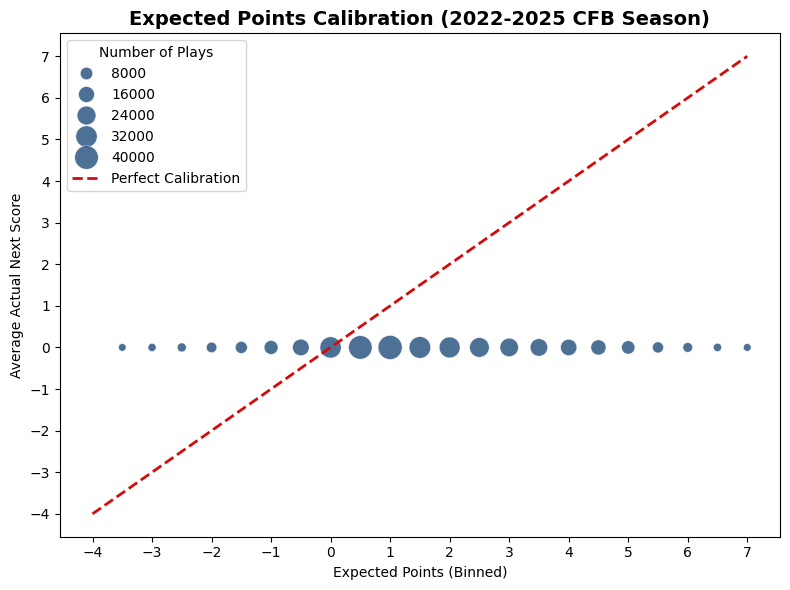

In [ ]:
def plot_calibration(df, bin_width=0.5, min_plays=50, title_suffix= "2022-2025 CFB Season"):
    df_copy = df.copy()
    df_copy['ep_bin'] = (df_copy['EP_after'] / bin_width).round() * bin_width

    cal_data = df_copy.groupby('ep_bin').agg(
        actual_pts=('pts_next_score', 'mean'),
        plays=('pts_next_score', 'count')
    ).reset_index()

    cal_data = cal_data[cal_data['plays'] >= min_plays]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=cal_data, x='ep_bin', y='actual_pts', size='plays', 
        sizes=(30, 300), color='#013369', alpha=0.7, ax=ax
    )
    ax.plot([-4, 7], [-4, 7], linestyle='--', color='#D50A0A', linewidth=2, label='Perfect Calibration')
    
    ax.set_xticks(range(-4, 8))
    ax.set_yticks(range(-4, 8))
    ax.set_title(f"Expected Points Calibration ({title_suffix})", fontweight='bold', fontsize=14)
    ax.set_xlabel("Expected Points (Binned)")
    ax.set_ylabel("Average Actual Next Score")
    ax.legend(title="Number of Plays", loc="upper left")
    plt.tight_layout()
    plt.show()

plot_calibration(pbp_filtered)


### Try 0.25 bin width

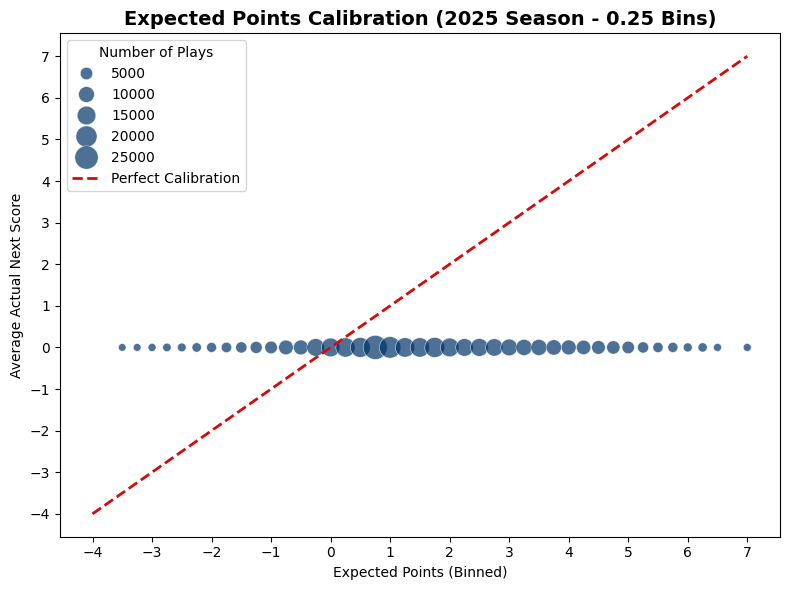

In [ ]:
# Task 1.2: 2025 Data Calibration
plot_calibration(pbp_filtered, bin_width=0.25, title_suffix="2025 Season - 0.25 Bins")

### Trying the Custom Linear Regression Drive Score Model

In [ ]:
pbp_filtered.columns

Index(['EP_start', 'game_id', 'half', 'fg_made', 'wp_before', 'touchdown',
       'pos_team', 'rush_td', 'pass_td', 'homeTeamName', 'awayTeamName',
       'def_pos_team', 'safety', 'home_scoring_event', 'pts_next_score'],
      dtype='str')

In [ ]:
model_data = pbp_filtered.sort_values(['game_id', 'play_id']).copy()

# 1. Post-play scores
model_data['home_score_post'] = np.where(
    model_data['pos_team'] == model_data['homeTeamName'],
    model_data['pos_team_score_post'],
    model_data['defteam_score_post']
)
model_data['away_score_post'] = np.where(
    model_data['posteam'] == model_data['away_team'],
    model_data['posteam_score_post'],
    model_data['defteam_score_post']
)

# 2. Group by game and drive
model_data = model_data[model_data['drive'].notna()].copy()

drive_summary = model_data.groupby(['game_id', 'drive']).agg(
    first_home_score=('total_home_score', 'first'),
    last_home_score=('home_score_post', 'last'),
    first_away_score=('total_away_score', 'first'),
    last_away_score=('away_score_post', 'last'),
    drive_posteam=('posteam', 'first')
).reset_index()

drive_summary['drive_home_pts'] = drive_summary['last_home_score'] - drive_summary['first_home_score']
drive_summary['drive_away_pts'] = drive_summary['last_away_score'] - drive_summary['first_away_score']

model_data = model_data.merge(
    drive_summary[['game_id', 'drive', 'drive_home_pts', 'drive_away_pts', 'drive_posteam']], 
    on=['game_id', 'drive'], how='left'
)

# 3. Calculate net drive score change
model_data['drive_score_change'] = np.where(
    model_data['drive_posteam'] == model_data['home_team'],
    model_data['drive_home_pts'] - model_data['drive_away_pts'],
    model_data['drive_away_pts'] - model_data['drive_home_pts']
)

# Filter missing predictors
model_data = model_data[
    model_data['down'].notna() &
    model_data['half_seconds_remaining'].notna() &
    model_data['yardline_100'].notna() &
    model_data['ydstogo'].notna() &
    model_data['goal_to_go'].notna() &
    (model_data['ydstogo'] > 0)
].copy()

model_data['log_ydstogo'] = np.log(model_data['ydstogo'])
model_data['under_two_minutes'] = (model_data['half_seconds_remaining'] <= 120).astype(int)
model_data['down'] = model_data['down'].astype(int) # took out .astype(str) from here?

# Fit OLS Model
ep_model = smf.ols(
    "drive_score_change ~ C(down) + half_seconds_remaining + yardline_100 + log_ydstogo + goal_to_go + under_two_minutes",
    data=model_data
).fit()

model_data['predicted_score_change'] = ep_model.predict(model_data)
print(ep_model.summary())

KeyError: 'play_id'

### Calibrating the Custom Linear Drive Score Model

In [ ]:
model_data['pred_bin'] = (model_data['predicted_score_change'] * 2).round() / 2

cal_custom = model_data.groupby('pred_bin').agg(
    actual_pts=('drive_score_change', 'mean'),
    plays=('drive_score_change', 'count')
).reset_index()

cal_custom = cal_custom[cal_custom['plays'] >= 50]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=cal_custom, x='pred_bin', y='actual_pts', size='plays', sizes=(30, 300), color='#013369', alpha=0.7, ax=ax)
ax.plot([-4, 7], [-4, 7], linestyle='--', color='#D50A0A', linewidth=2)
ax.set_xticks(range(-4, 8))
ax.set_yticks(range(-4, 8))
ax.set_title("Custom Model Calibration (Linear Regression)", fontweight='bold', fontsize=14)
ax.set_xlabel("Predicted Score Change (Binned)")
ax.set_ylabel("Average Actual Drive Score Change")
plt.tight_layout()
plt.show()

### Model Comparison: nflfastR EP vs. Custom Linear Model

In [ ]:
model_data['ep_bin'] = (model_data['ep'] * 4).round() / 4

comp_data = model_data.groupby('ep_bin').agg(
    avg_custom_pred=('predicted_score_change', 'mean'),
    plays=('predicted_score_change', 'count')
).reset_index()

comp_data = comp_data[comp_data['plays'] >= 50]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=comp_data, x='ep_bin', y='avg_custom_pred', size='plays', sizes=(30, 300), color='#013369', alpha=0.7, ax=ax)
ax.plot([-4, 7], [-4, 7], linestyle='--', color='#D50A0A', linewidth=2)
ax.set_xticks(range(-4, 8))
ax.set_yticks(range(-4, 8))
ax.set_title("Model Comparison: nflfastR EP vs. Custom Linear EP", fontweight='bold', fontsize=14)
ax.set_xlabel("Standard nflfastR EP (Binned)")
ax.set_ylabel("Average Custom Model Prediction")
plt.tight_layout()
plt.show()

### Non-Linearity Analysis: Field Position & Yards To Go Curves

In [ ]:
model_data['down'] = model_data['down'].astype(str)

In [ ]:
import numpy as np

def loess_smooth(x, y, frac=0.25, degree=1):
    """
    Fits a local polynomial regression (LOESS) with custom degree and span.
    
    Parameters:
    -----------
    x : array-like
        Independent variable data.
    y : array-like
        Dependent variable data.
    frac : float (default=0.25)
        Fraction of total points to include in local neighborhood (span).
    degree : int (default=1)
        Polynomial degree (0 = constant, 1 = linear, 2 = quadratic).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)
    k = max(int(np.ceil(frac * n)), degree + 1)
    
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.zeros_like(x_grid)
    
    for i, xi in enumerate(x_grid):
        distances = np.abs(x - xi)
        idx = np.argsort(distances)[:k]
        
        max_dist = distances[idx[-1]]
        if max_dist == 0:
            weights = np.ones(k)
        else:
            u = distances[idx] / max_dist
            weights = np.clip((1 - u**3)**3, 0, None)
            
        w_fit = np.sqrt(weights)
        
        if np.sum(weights) == 0:
            y_grid[i] = np.mean(y[idx])
        else:
            coeffs = np.polyfit(x[idx], y[idx], deg=degree, w=w_fit)
            y_grid[i] = np.polyval(coeffs, xi)
            
    return x_grid, y_grid

In [ ]:
# 1. Prepare and aggregate yards to go data
plot_ydstogo = (
    model_data[
        (model_data['down'].isin(['1','2', '3', '4'])) &
        (model_data['ydstogo'] >= 1) & (model_data['ydstogo'] <= 20)
    ]
    .groupby(['down', 'ydstogo'])
    .agg(
        nflfastR_EP=('ep', 'mean'),
        Custom_Linear_EP=('predicted_score_change', 'mean'),
        plays=('ep', 'count')
    )
    .reset_index()
)
plot_ydstogo = plot_ydstogo[plot_ydstogo['plays'] >= 10]

# --- Parameters to customize ---
FRAC_YDS = 0.4# Fractional window size (span)
DEGREE_YDS = 2  # 1 for linear, 2 for quadratic local fit
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
models = [('Standard nflfastR Model', 'nflfastR_EP'), ('Custom Linear Model', 'Custom_Linear_EP')]

for ax, (model_title, ep_col) in zip(axes, models):
    for down_val in ['1', '2', '3', '4']:
        sub = plot_ydstogo[plot_ydstogo['down'] == down_val]
        
        # Apply LOESS with custom frac and degree
        x_smooth, y_smooth = loess_smooth(
            sub['ydstogo'], sub[ep_col], frac=FRAC_YDS, degree=DEGREE_YDS
        )
        
        ax.plot(
            x_smooth, y_smooth, 
            label=f"Down {down_val}", 
            color=palette[down_val], 
            linewidth=2.5
        )
    
    ax.set_title(model_title, fontweight='bold', fontsize=12)
    ax.set_xlabel("Yards to Go (ydstogo)")
    ax.set_xticks(range(1, 21, 2))
    ax.set_ylabel("Expected Points (EP)" if ax == axes[0] else "")
    ax.grid(True, linestyle='--', alpha=0.6)

axes[1].legend(title="Down", bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle(f"Expected Points by Down and Yards to Go (frac={FRAC_YDS}, degree={DEGREE_YDS})", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()